### Import Libraries

In [1]:
# Core numerical and data libraries
import numpy as np
import pandas as pd

# Visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Model
from xgboost import XGBRegressor

### Load & Inspect Dataset

In [2]:
# Fetch the California housing dataset
california = fetch_california_housing()

# Convert to a DataFrame
df = pd.DataFrame(california.data, columns=california.feature_names)

# Add the target (median house price)
df["MedianValue"] = california.target

print("Preview of the dataset:")
display(df.head())

print("\nDataset shape:", df.shape)

print("\nMissing values per column:")
print(df.isnull().sum())


Preview of the dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Dataset shape: (20640, 9)

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedianValue    0
dtype: int64


### Summary Statistics & Correlation


Descriptive statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


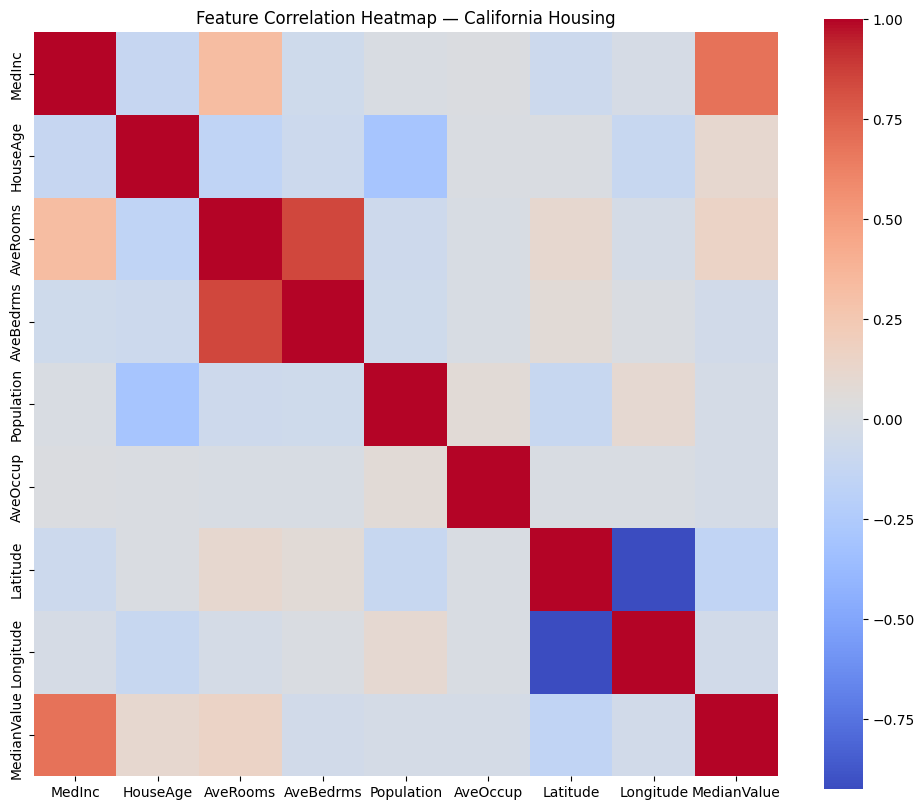

In [3]:
# Show descriptive stats
print("\nDescriptive statistics:")
display(df.describe())

# Compute correlation matrix
corr_matrix = df.corr()

# Visualize with heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    square=True,
    cbar=True
)
plt.title("Feature Correlation Heatmap — California Housing")
plt.show()


### Prepare Train/Test Splits

In [4]:
# Separate features (X) from target (y)
X = df.drop("MedianValue", axis=1)
y = df["MedianValue"]

print("Feature sample:")
display(X.head())

print("Target sample:")
display(y.head())

# Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nShapes:")
print("X:", X.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


Feature sample:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Target sample:


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedianValue, dtype: float64


Shapes:
X: (20640, 8)
X_train: (16512, 8)
X_test: (4128, 8)


### Train XGBoost Regressor

In [5]:
# Initialize the model
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("\nModel training complete.")


Model training complete.


### Training Evaluation


TRAINING PERFORMANCE:
R² Score: 0.917483790584888
Mean Absolute Error: 0.23141783015727013


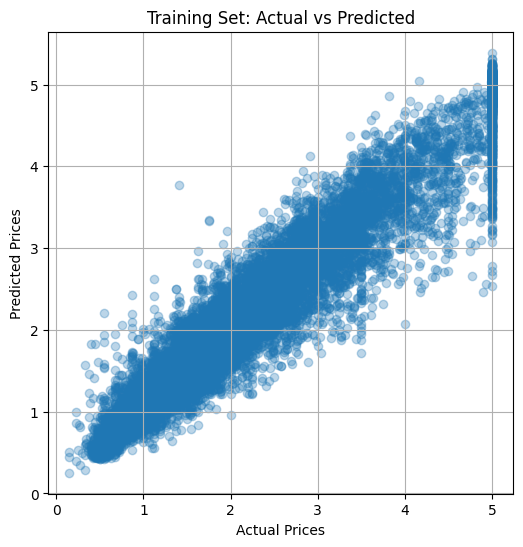

In [6]:
# Predict on the training data
train_preds = model.predict(X_train)

# Metrics
train_r2 = r2_score(y_train, train_preds)
train_mae = mean_absolute_error(y_train, train_preds)

print("\nTRAINING PERFORMANCE:")
print("R² Score:", train_r2)
print("Mean Absolute Error:", train_mae)

# Plot actual vs predicted values
plt.figure(figsize=(6, 6))
plt.scatter(y_train, train_preds, alpha=0.3)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Training Set: Actual vs Predicted")
plt.grid(True)
plt.show()


### Test Evaluation

In [7]:
# Predict on test data
test_preds = model.predict(X_test)

# Metrics
test_r2 = r2_score(y_test, test_preds)
test_mae = mean_absolute_error(y_test, test_preds)

print("\nTEST PERFORMANCE:")
print("R² Score:", test_r2)
print("Mean Absolute Error:", test_mae)



TEST PERFORMANCE:
R² Score: 0.8409717087687983
Mean Absolute Error: 0.2996458569715859
